# Predicting Student Performance from Gameplay Data

Project Link: https://www.kaggle.com/competitions/predict-student-performance-from-game-play/data

This project uses machine learning to predict student performance based on gameplay interaction data from the Kaggle “Predict Student Performance from Game Play” dataset.

## Overview

The objective of this project is to predict whether a student answers a question correctly based on their gameplay behavior. The dataset consists of event-level logs capturing user interactions such as clicks, elapsed time, and level progression.

Since the raw data is highly detailed and event-based, it is not directly suitable for machine learning models. Therefore, the data is aggregated by session_id to create meaningful session-level features such as average elapsed time, maximum level reached, and total number of interactions.

The problem is formulated as a binary classification task, where the goal is to predict whether a student’s answer is correct (1) or incorrect (0). A Random Forest classifier is used to model the relationship between gameplay behavior and student performance.

### Data Format

The dataset consists of tabular gameplay event data stored in CSV format, where each row represents a user interaction.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
train = pd.read_csv("train.csv")
labels = pd.read_csv("train_labels.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Labels shape:", labels.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample.shape)

Train shape: (26296946, 20)
Labels shape: (424116, 2)
Test shape: (3728, 21)
Sample submission shape: (54, 3)


The Dataset contains over 26 million rows and some feature columns.

In [4]:
train.head(6)


,session_id,index,elapsed_time,event_name,name,level,page,room_coor_x,room_coor_y,screen_coor_x,screen_coor_y,hover_duration,text,fqid,room_fqid,text_fqid,fullscreen,hq,music,level_group
0,20090312431273200,0,0,cutscene_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,undefined,intro,tunic.historicalsociety.closet,tunic.historicalsociety.closet.intro,0,0,1,0-4
1,20090312431273200,1,1323,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,"Whatcha doing over there, Jo?",gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
2,20090312431273200,2,831,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,Just talking to Teddy.,gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
3,20090312431273200,3,1147,person_click,basic,0,NaN,-413.991405,-159.314686,380.0,494.0,NaN,I gotta run to my meeting!,gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
4,20090312431273200,4,1863,person_click,basic,0,NaN,-412.991405,-159.314686,381.0,494.0,NaN,"Can I come, Gramps?",gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4
5,20090312431273200,5,3423,person_click,basic,0,NaN,-412.991405,-157.314686,381.0,492.0,NaN,"Sure thing, Jo. Grab your notebook and come up...",gramps,tunic.historicalsociety.closet,tunic.historicalsociety.closet.gramps.intro_0_...,0,0,1,0-4


In [5]:
labels.head(6)

,session_id,correct
0,20090312431273200_q1,1
1,20090312433251036_q1,0
2,20090312455206810_q1,1
3,20090313091715820_q1,0
4,20090313571836404_q1,1
5,20090314035813970_q1,1


### Data Visualization

In [6]:
labels_viz = labels.copy()

labels_viz["session"] = labels_viz["session_id"].astype(str).str.split("_").str[0]
labels_viz["question"] = labels_viz["session_id"].astype(str).str.split("_").str[1]

labels_viz.head()

,session_id,correct,session,question
0,20090312431273200_q1,1,20090312431273200,q1
1,20090312433251036_q1,0,20090312433251036,q1
2,20090312455206810_q1,1,20090312455206810,q1
3,20090313091715820_q1,0,20090313091715820,q1
4,20090313571836404_q1,1,20090313571836404,q1


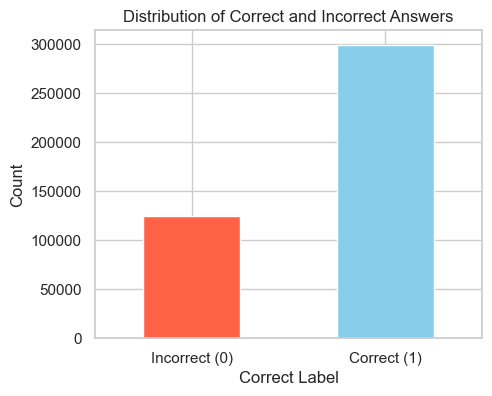

In [7]:
plt.figure(figsize=(5, 4))

labels_viz["correct"].value_counts().sort_index().plot(
    kind="bar",
    color=["tomato", "skyblue"]
)

plt.title("Distribution of Correct and Incorrect Answers")
plt.xlabel("Correct Label")
plt.ylabel("Count")
plt.xticks([0, 1], ["Incorrect (0)", "Correct (1)"], rotation=0)
plt.show()

The overall distribution of correct and incorrect answers.

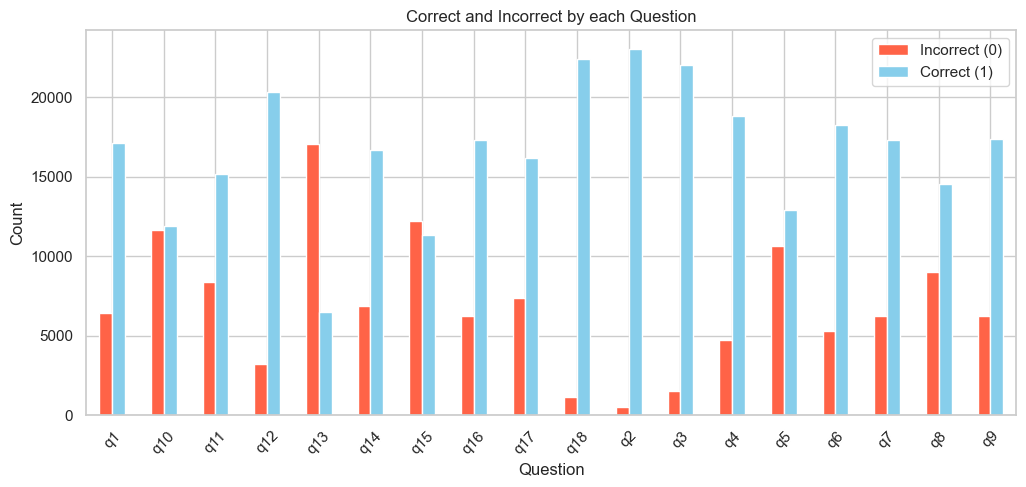

In [8]:
question_counts = labels_viz.groupby(["question", "correct"]).size().unstack(fill_value=0)

question_counts.plot(
    kind="bar",
    figsize=(12,5),
    color=["tomato", "skyblue"]
)

plt.title("Correct and Incorrect by each Question")
plt.xlabel("Question")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["Incorrect (0)", "Correct (1)"])
plt.show()

The graph shows that some questions have higher correct rates than others. This means that certain questions may be easier, while others may be more difficult for students. 

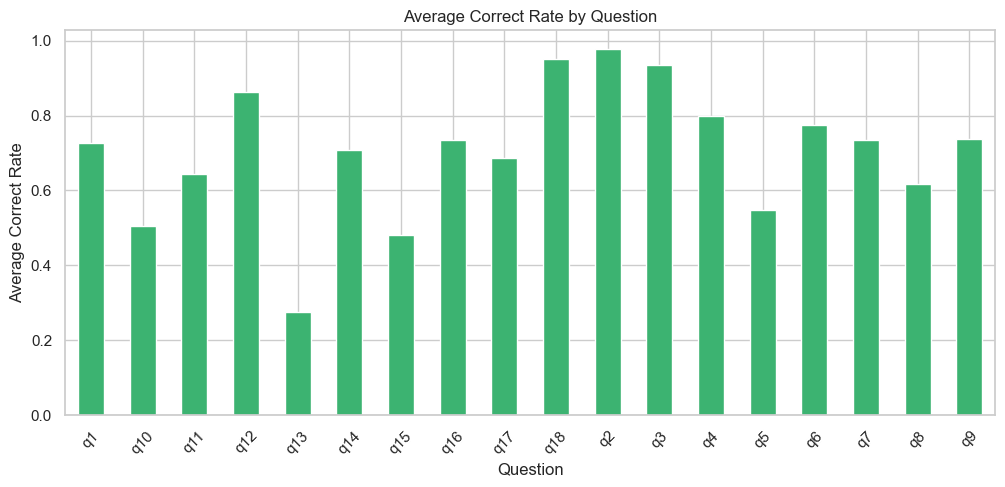

In [9]:
plt.figure(figsize=(12, 5))

question_correct = labels_viz.groupby("question")["correct"].mean()

question_correct.plot(kind="bar", color="mediumseagreen")

plt.title("Average Correct Rate by Question")
plt.xlabel("Question")
plt.ylabel("Average Correct Rate")
plt.xticks(rotation=45)
plt.show()

### Preparing the dataset

In [11]:
CATEGORICAL = ["event_name", "name", "room_fqid", "level_group"]
NUMERICAL = ["elapsed_time", "level"]

def feature_engineer(df):
    dfs = []

    for col in CATEGORICAL:
        temp = df.groupby(["session_id", "level_group"])[col].nunique()
        temp.name = col + "_nunique"
        dfs.append(temp)

    for col in NUMERICAL:
        temp = df.groupby(["session_id", "level_group"])[col].mean()
        temp.name = col + "_mean"
        dfs.append(temp)

    for col in NUMERICAL:
        temp = df.groupby(["session_id", "level_group"])[col].std()
        temp.name = col + "_std"
        dfs.append(temp)

    features = pd.concat(dfs, axis=1)
    features = features.fillna(-1)
    features = features.reset_index()

    return features

features = feature_engineer(train)

print("Prepared dataset shape:", features.shape)
features.head()

Prepared dataset shape: (70686, 10)


,session_id,level_group,event_name_nunique,name_nunique,room_fqid_nunique,level_group_nunique,elapsed_time_mean,level_mean,elapsed_time_std,level_std
0,20090312431273200,0-4,10,3,7,1,8.579356e+04,1.945455,49246.539458,1.230975
1,20090312431273200,13-22,10,3,12,1,1.040601e+06,17.402381,126666.129584,2.358652
2,20090312431273200,5-12,10,3,11,1,3.572052e+05,8.054054,80175.676658,2.096919
3,20090312433251036,0-4,11,4,6,1,9.763342e+04,1.870504,67372.714092,1.232616
4,20090312433251036,13-22,11,6,16,1,2.498852e+06,17.762529,777382.529186,1.825923


The prepared dataset now contains one row for each session and level_group combination

In [12]:
labels_clean = labels.copy()

labels_clean["base_session"] = labels_clean["session_id"].astype(str).str.split("_").str[0]
labels_clean["question"] = labels_clean["session_id"].astype(str).str.split("_").str[1]

labels_clean.head()

,session_id,correct,base_session,question
0,20090312431273200_q1,1,20090312431273200,q1
1,20090312433251036_q1,0,20090312433251036,q1
2,20090312455206810_q1,1,20090312455206810,q1
3,20090313091715820_q1,0,20090313091715820,q1
4,20090313571836404_q1,1,20090313571836404,q1


In [13]:
features["session_id"] = features["session_id"].astype(str)
labels_clean["base_session"] = labels_clean["base_session"].astype(str)

data = features.merge(
    labels_clean,
    left_on="session_id",
    right_on="base_session",
    how="inner"
)

data.head()

,session_id_x,level_group,event_name_nunique,name_nunique,room_fqid_nunique,level_group_nunique,elapsed_time_mean,level_mean,elapsed_time_std,level_std,session_id_y,correct,base_session,question
0,20090312431273200,0-4,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975,20090312431273200_q1,1,20090312431273200,q1
1,20090312431273200,0-4,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975,20090312431273200_q2,1,20090312431273200,q2
2,20090312431273200,0-4,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975,20090312431273200_q3,1,20090312431273200,q3
3,20090312431273200,0-4,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975,20090312431273200_q4,1,20090312431273200,q4
4,20090312431273200,0-4,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975,20090312431273200_q5,1,20090312431273200,q5


In [14]:
data.shape

(1272348, 14)

In [15]:

drop_cols = ["session_id_x", "session_id_y", "base_session", "question", "level_group"]

X = data.drop(columns=drop_cols + ["correct"])
y = data["correct"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (1272348, 8)
y shape: (1272348,)


,event_name_nunique,name_nunique,room_fqid_nunique,level_group_nunique,elapsed_time_mean,level_mean,elapsed_time_std,level_std
0,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975
1,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975
2,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975
3,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975
4,10,3,7,1,85793.557576,1.945455,49246.539458,1.230975


Seleted the final input by dropping input and the target coulumn

In [16]:

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1017878, 8)
X_val: (254470, 8)
y_train: (1017878,)
y_val: (254470,)


Is is split into training and validation set

### Training the model

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, rf_pred))
print(classification_report(y_val, rf_pred))

Random Forest Accuracy: 0.6205014343537548
              precision    recall  f1-score   support

           0       0.40      0.56      0.47     74907
           1       0.78      0.64      0.71    179563

    accuracy                           0.62    254470
   macro avg       0.59      0.60      0.59    254470
weighted avg       0.67      0.62      0.64    254470



Trained a random forest model for classification task

Validation ROC AUC Score: 0.6414


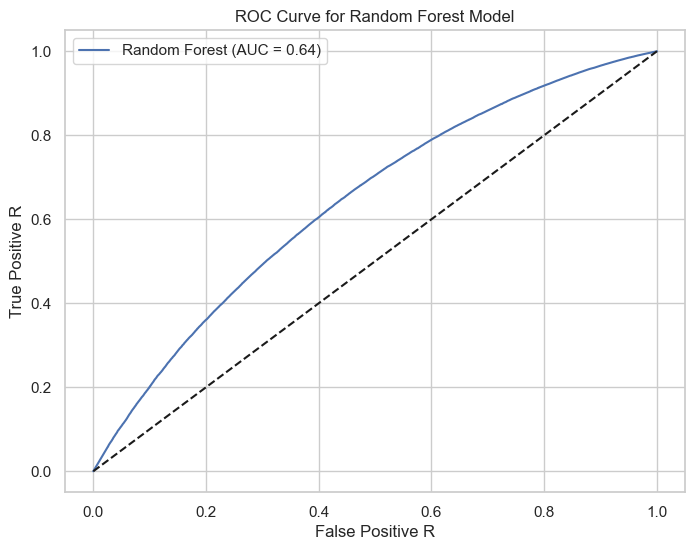

In [20]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get prediction probabilities for validation set
val_probs = rf_model.predict_proba(X_val)[:, 1]

# ROC AUC score
auc_score = roc_auc_score(y_val, val_probs)

print(f"Validation ROC AUC Score: {auc_score:.4f}")

# ROC curve
fpr, tpr, thresholds = roc_curve(y_val, val_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive R")
plt.ylabel("True Positive R")
plt.title("ROC Curve for Random Forest Model")
plt.legend()
plt.show()

The curve shows how does the model seperates correct and incorrect answers.

In [22]:
import numpy as np
from sklearn.metrics import f1_score

# validation probabilities
val_probs = rf_model.predict_proba(X_val)[:, 1]

best_threshold = 0
best_f1 = 0

# thres from 0.40 to 0.79
for threshold in np.arange(0.40, 0.80, 0.01):
    val_pred_threshold = (val_probs >= threshold).astype(int)
    f1 = f1_score(y_val, val_pred_threshold)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", round(best_threshold, 2))
print("Best F1 score:", round(best_f1, 4))

Best threshold: 0.4
Best F1 score: 0.7758


I tested different probability thresholds from 0.40 to 0.79 using the validation set.

In [29]:
test_features = feature_engineer(test)

test_features["session_id"] = test_features["session_id"].astype(str)

X_test = test_features.drop(columns=["session_id", "level_group"])

# Make sure test columns match training columns exactly
X_test = X_test[X.columns]

X_test.head()

,event_name_nunique,name_nunique,room_fqid_nunique,level_group_nunique,elapsed_time_mean,level_mean,elapsed_time_std,level_std
0,11,4,6,1,1.171198e+05,2.050000,6.661989e+04,1.348194
1,11,4,12,1,6.165666e+06,17.918089,2.277512e+05,2.279627
2,11,4,12,1,2.092368e+06,7.686567,2.124842e+06,1.898028
3,11,4,7,1,1.424183e+05,1.803681,7.825763e+04,1.221509
4,11,6,15,1,2.195108e+06,17.335626,3.078757e+05,2.688642


In [30]:
test_probs = rf_model.predict_proba(X_test)[:, 1]

test_predictions = (test_probs >= best_threshold).astype(int)

print(test_predictions[:10])

[1 1 1 1 1 0 1 1 1]


In [37]:
sample = pd.read_csv("sample_submission.csv")

sample["base_session"] = sample["session_id"].str.split("_").str[0].astype(str)

# Converting session_level number into level_groups
def map_level_group(level):
    if level <= 4:
        return "0-4"
    elif level <= 12:
        return "5-12"
    else:
        return "13-22"

sample["level_group"] = sample["session_level"].apply(map_level_group)

pred_df = pd.DataFrame({
    "base_session": test_features["session_id"].astype(str),
    "level_group": test_features["level_group"].astype(str),
    "predicted_correct": test_predictions
})

final_submission = sample.merge(
    pred_df,
    on=["base_session", "level_group"],
    how="left"
)

final_submission["correct"] = final_submission["predicted_correct"]

final_submission = final_submission[["session_id", "correct", "session_level"]]

final_submission.to_csv("submission.csv", index=False)

final_submission.head(5)

,session_id,correct,session_level
0,20090109393214576_q1,1,0
1,20090312143683264_q1,1,3
2,20090312331414616_q1,1,6
3,20090109393214576_q2,1,0
4,20090312143683264_q2,1,3


The model estimates whether the student will be correct based on the data for a particular unique session. The predictions are grouped by session_id and level_group, so the predictions are based on the student’s interactions in a certain portion of the game rather than random sampling.

## Conclusion


This project used gameplay data to predict whether students would answer correctly. The Random Forest model achieved decent performance with about 62% validation accuracy and a ROC AUC score of about 0.64. This shows that gameplay behavior can help predict student performance. With improvements model can work more accurately.

### Future Work

I would love to improve this project by creating stronger features as question specific behavior with more time before each question. Also,  I would also try with other available datasets on  different models.